In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data

y = iris.target

In [2]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
cluster_ids = kmeans.fit_predict(iris.data)



There is no need to find an "optimal" K since we are working with the iris dataset we know there should be 3 clusters.

Species Mapping: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}


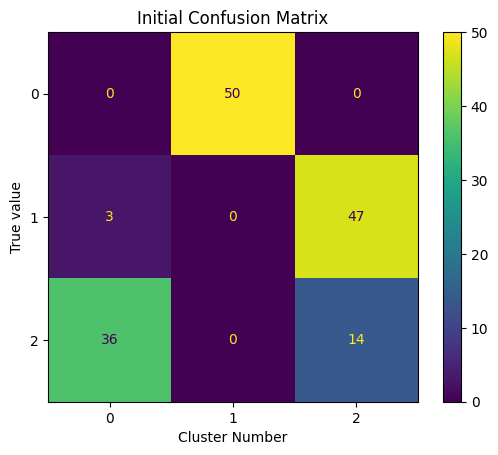

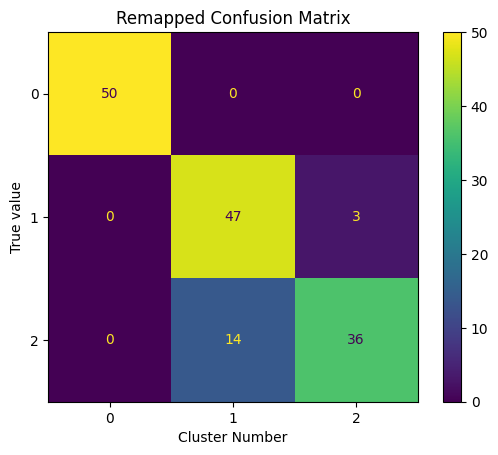

Accuracy Score: 0.8866666666666667


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment
from sklearn . metrics import ConfusionMatrixDisplay

species_map = {i: name for i, name in enumerate(iris.target_names)}
print("Species Mapping:", species_map)

cm = confusion_matrix(iris.target, cluster_ids)

row_ind, col_ind = linear_sum_assignment(-cm)
id_to_true_map = {col: row for row, col in zip(row_ind, col_ind)}

y_pred_remapped = np.array([id_to_true_map[c] for c in cluster_ids])

y_pred_names = [species_map[val] for val in y_pred_remapped]

display=ConfusionMatrixDisplay ( confusion_matrix=cm, display_labels=species_map)
display.plot()
plt .ylabel("True value")
plt .xlabel("Cluster Number")
plt.title("Initial Confusion Matrix")
plt .show()

kmeans_conf_matrix=confusion_matrix(iris.target, y_pred_remapped)
display=ConfusionMatrixDisplay ( confusion_matrix=kmeans_conf_matrix,display_labels=species_map)
display.plot()
plt .ylabel("True value")
plt .xlabel("Cluster Number")
plt.title("Remapped Confusion Matrix")
plt .show()
kmeans_accuracy=accuracy_score(y, y_pred_remapped)
print("Accuracy Score:", kmeans_accuracy)


In [ ]:
from sklearn.cluster import AgglomerativeClustering
optimal_clusters = 3
hca = AgglomerativeClustering(n_clusters=optimal_clusters, metric='euclidean', linkage='ward')
y_pred = hca.fit_predict(iris.data)

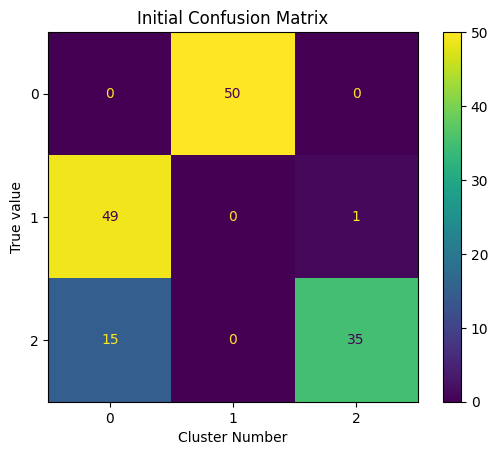

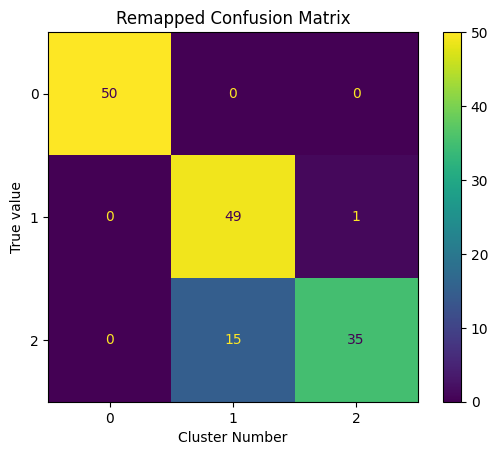

Accuracy Score: 0.8933333333333333


In [ ]:
from scipy.optimize import linear_sum_assignment

cm = confusion_matrix(iris.target, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm)
display.plot()
plt .ylabel("True value")
plt .xlabel("Cluster Number")
plt.title("Initial Confusion Matrix")
plt .show()

row_ind, col_ind = linear_sum_assignment(-cm)
cluster_to_true_map = {col: row for row, col in zip(row_ind, col_ind)}

y_remapped = np.array([cluster_to_true_map[c] for c in y_pred])

hca_conf_matrix=confusion_matrix(y, y_remapped)

display=ConfusionMatrixDisplay ( confusion_matrix=hca_conf_matrix)
display.plot()
plt .ylabel("True value")
plt .xlabel("Cluster Number")
plt.title("Remapped Confusion Matrix")
plt .show()
hca_accuracy=accuracy_score(y, y_remapped)
print("Accuracy Score:", hca_accuracy)

In [23]:
print(species_map)

{0: 'setosa', 1: 'versicolor', 2: 'virginica'}


## Comparison:
both models have similar accuracy (88%, 89%) and both only seem to have misclassified the virginica class as versicolor as their main error.

## Conclusion:
both models perfectly isolate the Setosa class but struggle to differentiate between Virginica and Versicolor. This is a common outcome for the Iris dataset because while Setosa is linearly separable, the other two species overlap significantly in their feature measurements (specifically petal length and width). This overlap causes both K-Means (which uses centroids) and HCA (which uses hierarchical merges) to misclassify several Virginica samples as Versicolor, marking the primary performance bottleneck for both algorithms.